# Physics explorer

Every system, every parameter, every graph - and no transformer anywhere in this
notebook, so it loads and runs on a machine with no model installed.

The question it exists to answer is **which parameter settings give a usable
trajectory**, which has to be settled before a single token from a setting is worth
training on. So every panel draws two runs from the same release condition:

- **driven** - the chain's letters land as impulses, one per tick;
- **free** - the identical system with no kicks at all.

The gap between them is the entire causal footprint of the chain. If it is invisible
the dataset carries no signal; if it explodes the dataset is measuring the velocity
clamps rather than the physics. A third, invisible run starts `1e-8` away from the
driven one and never appears in a panel except as the red line in `divergence`: it
measures the system's own sensitivity to initial conditions, independent of how hard
the chain is kicking it.

The verdict box beside the sliders turns that into four separable failure modes:

| number | fails when | means |
|---|---|---|
| `lyapunov` | `> 0.05 /s` | the trajectory forgets its own initial condition - chaotic |
| `clipped` | `> 1%` | the observable leaves its range and the tokens saturate |
| `gap driven-vs-free` | `< 1e-3` | the kicks leave no trace to learn from |
| `bins used` | `< 10%` | most of the vocabulary is never emitted |


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from physics import visualise as V
from physics.controls import explorer, sweep_ui, optimal_gamma_ui, grid_screen, grid_screen_ui, n_recalibrate, display_grid
from physics.visualise import auto_dt
from physics.messk_configs import MESSK_CONFIGS, make_process

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.4})
print(sorted(MESSK_CONFIGS))

['double_pendulum_mess4', 'pendulum_mess4', 'predator_prey_mess4', 'sphere_mess4']


## 1. The explorer

Every slider carries its own **range** boxes on the right. The slider is for feel;
retype a bound to leave the neighbourhood entirely. `gamma` defaults around 1.2, so
its slider starts at 0-3.4 - type `50` into the right-hand box and drag to 50.

The system sliders are read off the dataclass itself, so a field added to a system
in `physics/systems/` appears here with no edit to this notebook.

`bins per channel` takes `181` (one channel, the vocabulary every committed run used)
or `181x181` (two channels combined into one token, vocabulary 32761).

Ten graphs are available in the `graphs` box - shift-click or ctrl-click to pick any
combination:

`observable` the channel and the token it becomes, with the range edges in red and a
dotted line at every kick &middot; `energy` injection versus dissipation &middot;
`metric` the physical quantity the probe targets &middot; `phase` the portrait, on the
sphere itself for the spherical pendulum &middot; `states` every state coordinate
&middot; `divergence` both gaps on a log axis, with the fitted exponent &middot;
`spectrum` a clean peak means periodic, broadband means chaotic &middot; `tokens`
which of the vocabulary this sequence actually uses &middot; `belief` the exact
predictive belief, identical across all four systems by construction &middot;
`return_map` `obs[n+1]` against `obs[n]`, a thin curve when deterministic.

In [5]:
w = explorer("double_pendulum_mess4")
display(w)

## 2. Where is it stable?

The explorer answers "is *this* setting stable". This scans one parameter across a
range and answers "which settings are", which is the question you actually have when
choosing a default.

Worth running first: `double_pendulum` over `gamma1` from 0 to 8. The Lyapunov
exponent crosses zero somewhere in the middle, and that crossing is the boundary
between a system whose tokens are predictable from its own history and one whose
are not.

In [6]:
display(sweep_ui("double_pendulum_mess4"))

## 3. All four side by side

The chain, the tick structure and the bin count are common to every system by
construction, so the belief is literally the same object in all four runs. What
differs is only the physical channel it passes through - which is what makes this
comparison mean something rather than being four unrelated plots.

Below we compare both the continuous physical observables and the discrete token space
(showing the 1D histograms alongside the 2D Cartesian 30×30 grid for `sphere_mess4`).

=== 1. Physical Observables Across All Four Systems ===


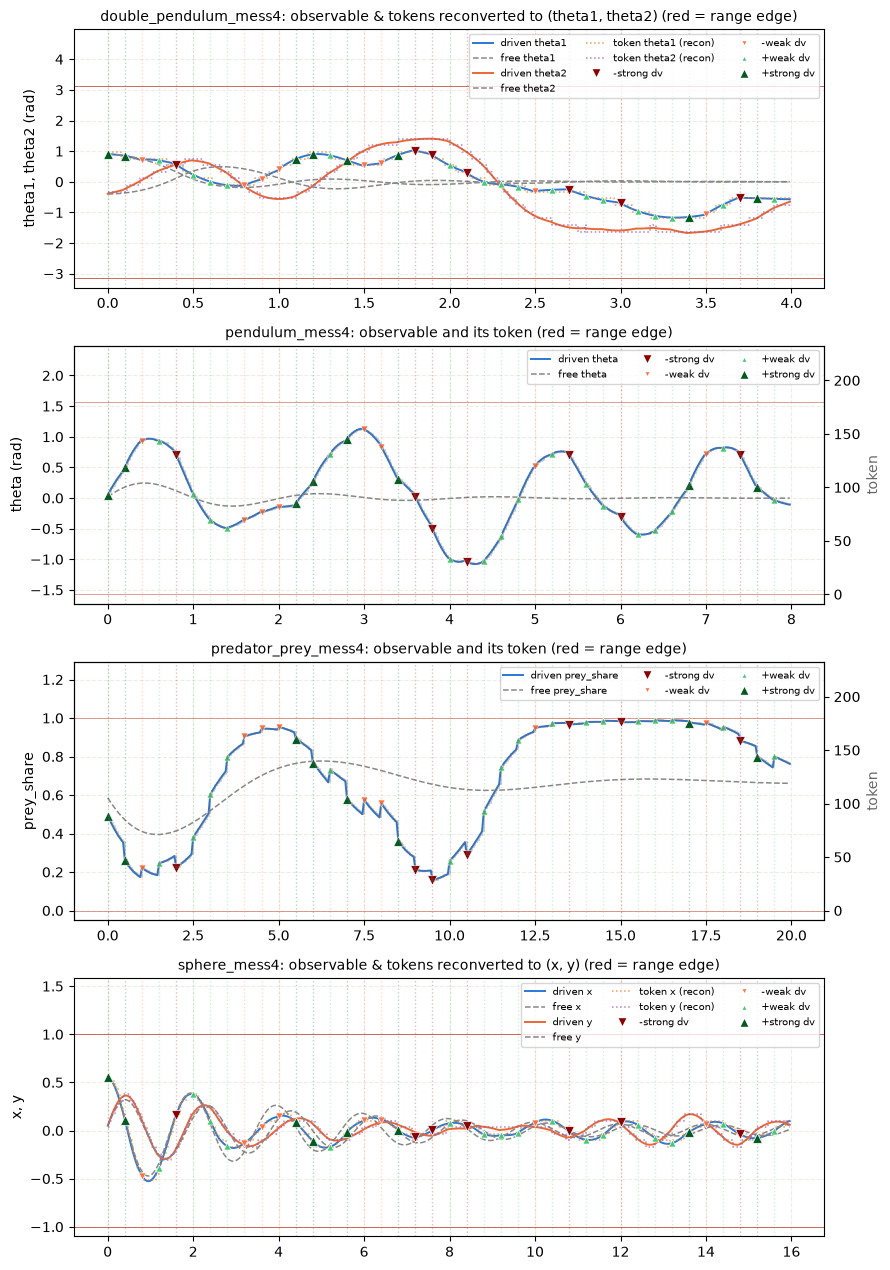

=== 2. Discrete Token Space Across All Four Systems (1D Histograms vs 2D Cartesian Grid) ===


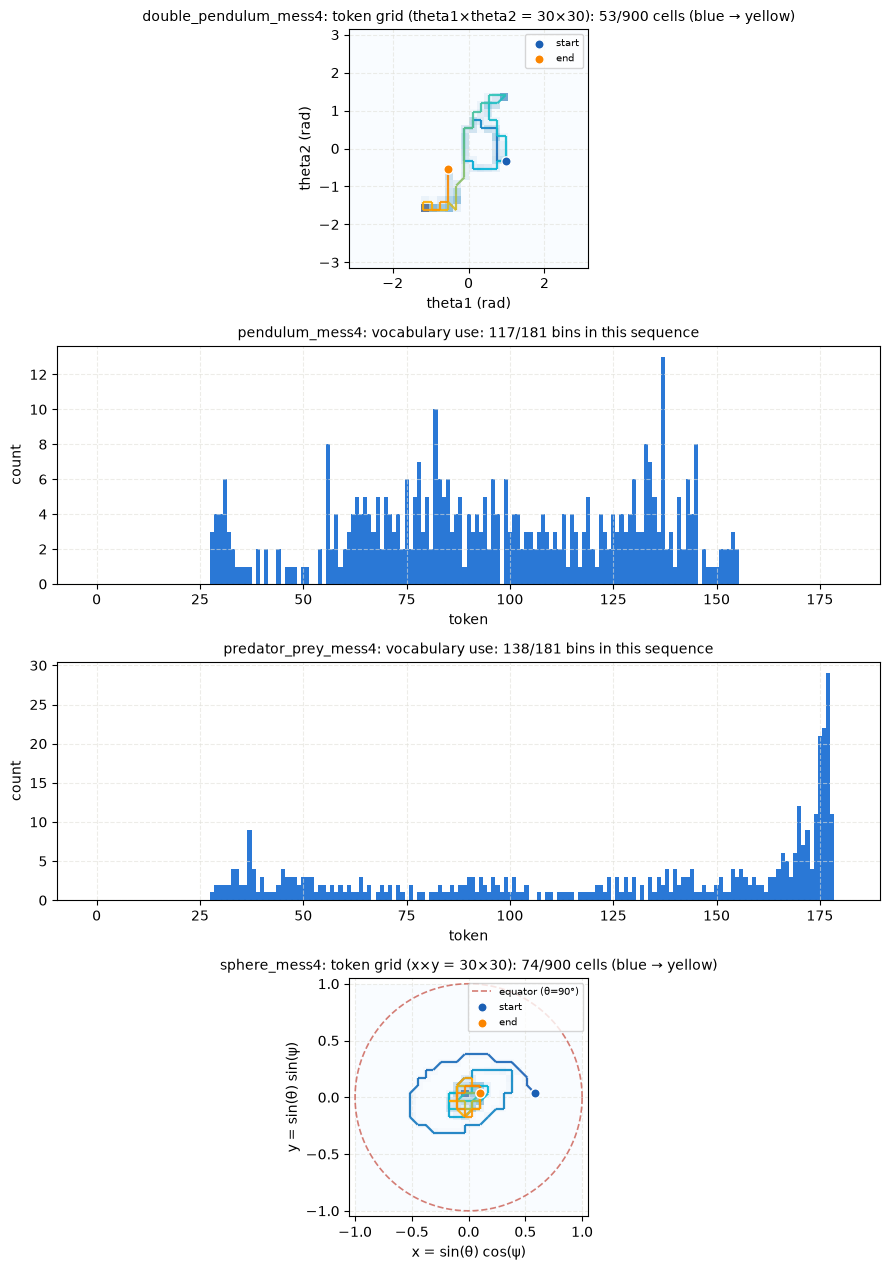

In [7]:
M_TICKS = 40
SEED = 1

traces = {name: V.trace(make_process(name, m=M_TICKS), seed=SEED)
          for name in sorted(MESSK_CONFIGS)}

print("=== 1. Physical Observables Across All Four Systems ===")
fig_obs = V.compare(traces, panel="observable")
plt.show()

print("=== 2. Discrete Token Space Across All Four Systems (1D Histograms vs 2D Cartesian Grid) ===")
fig_tok = V.compare(traces, panel="tokens")
plt.show()

## 4. The stability table

Every system at its committed defaults, scored by the same four numbers. This is the
row to re-run after changing any default in `physics/systems/` or
`physics/messk_configs.py`.

In [8]:
import pandas as pd

rows = []
for name, tr in traces.items():
    s = V.stability(tr)
    rows.append({
        "system": name,
        "lyapunov": round(s["lyapunov"], 3),
        "clipped %": round(100 * s["clipped"], 2),
        "bins used": f"{s['used_bins']}/{s['n_obs']}",
        "gap mean": round(s["gap_free_mean"], 3),
        "energy drift %": round(100 * s["energy_drift_free"], 1),
        "stable": s["stable"],
        "why not": "; ".join(s["reasons"]),
    })
print("=== Single-Seed Stability Evaluation (Seed 1) ===")
display(pd.DataFrame(rows).set_index("system"))

# Multi-seed stability protocol (10 seeds: 0 to 9) for rigorous evaluation
print("\n=== Multi-Seed Stability Protocol (10 Seeds: Mean ± Std Dev) ===")
multi_rows = []
for name in sorted(MESSK_CONFIGS):
    lyap_list, clip_list, bins_list, pass_list = [], [], [], []
    for s in range(10):
        proc_s = make_process(name, m=M_TICKS)
        tr_s = V.trace(proc_s, seed=s)
        stab_s = V.stability(tr_s)
        lyap_list.append(stab_s["lyapunov"])
        clip_list.append(stab_s["clipped"] * 100)
        bins_list.append(stab_s["used_bins"])
        pass_list.append(stab_s["stable"])
    multi_rows.append({
        "system": name,
        "lyapunov (mean ± std)": f"{np.mean(lyap_list):+.3f} ± {np.std(lyap_list):.3f}",
        "clipped %": f"{np.mean(clip_list):.2f}% ± {np.std(clip_list):.2f}%",
        "bins used": f"{np.mean(bins_list):.1f} ± {np.std(bins_list):.1f}",
        "pass rate": f"{sum(pass_list)}/10 ({sum(pass_list)*10}%)",
    })
display(pd.DataFrame(multi_rows).set_index("system"))

=== Single-Seed Stability Evaluation (Seed 1) ===


,lyapunov,clipped %,bins used,gap mean,energy drift %,stable,why not
system,,,,,,,
double_pendulum_mess4,-0.535,0.0,53/900,3.078,-38.6,True,
pendulum_mess4,-0.538,0.0,117/181,1.554,-5.4,True,
predator_prey_mess4,-0.058,0.0,138/181,1.543,-99.9,True,
sphere_mess4,-0.051,0.0,74/900,0.314,-31.1,True,



=== Multi-Seed Stability Protocol (10 Seeds: Mean ± Std Dev) ===


,lyapunov (mean ± std),clipped %,bins used,pass rate
system,,,,
double_pendulum_mess4,-0.415 ± 0.353,0.00% ± 0.00%,63.9 ± 14.5,9/10 (90%)
pendulum_mess4,-0.517 ± 0.226,5.05% ± 12.84%,120.9 ± 9.3,7/10 (70%)
predator_prey_mess4,-0.132 ± 0.062,0.00% ± 0.00%,129.1 ± 13.2,10/10 (100%)
sphere_mess4,-0.075 ± 0.072,0.00% ± 0.00%,82.1 ± 14.2,9/10 (90%)


## 5. One letter's causal effect

Replay one sequence with every possible letter at a single tick. The trajectories
agree exactly up to that tick and differ afterwards only because of that one impulse,
so the spread below is the whole of what a model could ever infer about that letter.

This is the panel that says whether the four actions are *distinguishable*. Below we visualize
the 4 counterfactual letter branches for `sphere_mess4` on the 2D Cartesian $(x, y)$ grid plane,
confirming non-collapsing bifurcation and bounded pairwise separation in token units.

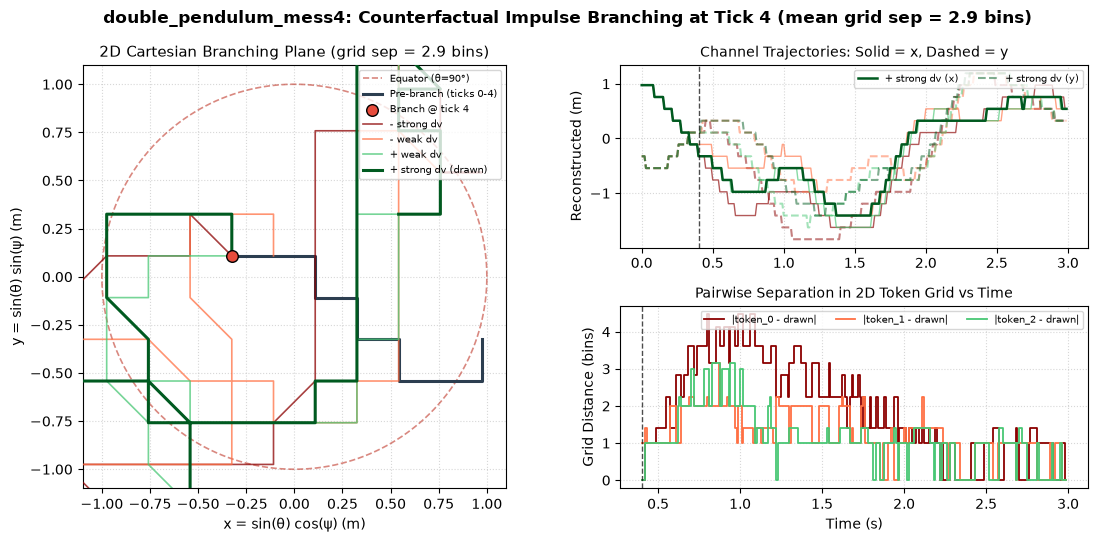

mean pairwise token separation after the branch: grid sep = 2.9 bins


In [9]:
SYSTEM = "double_pendulum_mess4"
TICK = 4

proc = make_process(SYSTEM, m=30)
rng = np.random.default_rng(0)
letters = proc.chain.sample(rng, 1, proc.m)[1][0]
variants = np.tile(letters, (proc.chain.n_states, 1))
variants[:, TICK] = np.arange(proc.chain.n_states)
out = proc.rollout(variants)

obs = out["observable"]  # (4, seq_len, 2)
tokens = out["tokens"]   # (4, seq_len)
recon = proc.undiscretise(tokens)  # (4, seq_len, 2)
t = np.arange(proc.seq_len) * proc.dt
branch_idx = TICK * proc.n_steps
t_branch = branch_idx * proc.dt

indices = proc.tokens_to_indices(tokens[:, branch_idx:])
diff = indices[:, None, :, :] - indices[None, :, :, :]
sep_matrix = np.linalg.norm(diff, axis=-1)
mean_sep = sep_matrix.max(-1).mean()
sep_str = f"grid sep = {mean_sep:.1f} bins"

fig = plt.figure(figsize=(13, 5.5))
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1.2], hspace=0.32, wspace=0.25)
ax_map = fig.add_subplot(gs[:, 0])
ax_coord = fig.add_subplot(gs[0, 1])
ax_sep = fig.add_subplot(gs[1, 1])

# Left: 2D Cartesian Trajectory Branching
th_circ = np.linspace(0, 2 * np.pi, 200)
ax_map.plot(np.cos(th_circ), np.sin(th_circ), color="#c0392b", ls="--", lw=1.2, alpha=0.6, label="Equator (θ=90°)")
ax_map.plot(recon[letters[TICK], :branch_idx+1, 0], recon[letters[TICK], :branch_idx+1, 1],
            color="#2c3e50", lw=2.2, label="Pre-branch (ticks 0-4)")
ax_map.scatter(recon[letters[TICK], branch_idx, 0], recon[letters[TICK], branch_idx, 1],
               color="#e74c3c", s=70, zorder=7, edgecolors="k", label=f"Branch @ tick {TICK}")

for l in range(proc.chain.n_states):
    is_drawn = (l == letters[TICK])
    cfg = V.ticker_for_letter(l)
    style = dict(lw=2.2, alpha=1.0, zorder=5) if is_drawn else dict(lw=1.2, alpha=0.75, zorder=4)
    name = cfg["name"] + (" (drawn)" if is_drawn else "")
    ax_map.plot(recon[l, branch_idx:, 0], recon[l, branch_idx:, 1],
                color=cfg["color"], label=name, **style)

ax_map.set_xlim(-1.1, 1.1)
ax_map.set_ylim(-1.1, 1.1)
ax_map.set_aspect("equal")
ax_map.set_xlabel("x = sin(θ) cos(ψ) (m)")
ax_map.set_ylabel("y = sin(θ) sin(ψ) (m)")
ax_map.set_title(f"2D Cartesian Branching Plane ({sep_str})", fontsize=10.5)
ax_map.legend(fontsize=7, loc="upper right")
ax_map.grid(True, ls=":", alpha=0.5)

# Top Right: Reconstructed Coordinates (x, y) vs Time
for l in range(proc.chain.n_states):
    is_drawn = (l == letters[TICK])
    cfg = V.ticker_for_letter(l)
    cname = cfg["name"]
    style = dict(lw=1.8, alpha=1.0) if is_drawn else dict(lw=1.0, alpha=0.65)
    ax_coord.plot(t, recon[l, :, 0], color=cfg["color"], ls="-",
                  label=f"{cname} (x)" if is_drawn else None, **style)
    ax_coord.plot(t, recon[l, :, 1], color=cfg["color"], ls="--", alpha=0.5,
                  label=f"{cname} (y)" if is_drawn else None)

ax_coord.axvline(t_branch, color="k", ls="--", lw=1, alpha=0.7)
ax_coord.set_ylabel("Reconstructed (m)")
ax_coord.set_title("Channel Trajectories: Solid = x, Dashed = y", fontsize=10)
ax_coord.legend(fontsize=7, ncol=2, loc="upper right")
ax_coord.grid(True, ls=":", alpha=0.5)

# Bottom Right: Pairwise Token Distance from Drawn Letter
drawn_idx = indices[letters[TICK]]
t_after = t[branch_idx:]
for l in range(proc.chain.n_states):
    if l == letters[TICK]:
        continue
    cfg = V.ticker_for_letter(l)
    dist_l = np.linalg.norm(indices[l] - drawn_idx, axis=-1)
    ax_sep.step(t_after, dist_l, color=cfg["color"], where="post", lw=1.3,
                label=f"|token_{l} - drawn|")

ax_sep.axvline(t_branch, color="k", ls="--", lw=1, alpha=0.7)
ax_sep.set_xlabel("Time (s)")
ax_sep.set_ylabel("Grid Distance (bins)")
ax_sep.set_title("Pairwise Separation in 2D Token Grid vs Time", fontsize=10)
ax_sep.legend(fontsize=7, ncol=3, loc="upper right")
ax_sep.grid(True, ls=":", alpha=0.5)

fig.suptitle(f"{SYSTEM}: Counterfactual Impulse Branching at Tick {TICK} (mean {sep_str})",
             fontsize=12, fontweight="bold")
plt.show()
print(f"mean pairwise token separation after the branch: {sep_str}")

## 6. Steady-State Energy Balance: Optimal Viscous Damping ($\\gamma^*$)

Computes the exact damping parameter $\\gamma^*$ where the average energy dissipated by viscous friction ($\\frac{dE}{dt} = -\\gamma \\omega^2$) exactly balances the average energy injected by the momentum perturbation kicks:

$$\\langle \\Delta E_{\\text{injected}} \\rangle = \\langle \\Delta E_{\\text{dissipated}} \\rangle$$

Use the sliders below to adjust $m$ (total ticks), $n$ (integration steps per tick), $dt$, $\\delta v$ (kick scale), $\\text{stay}$, and $\\alpha$ to find the optimal $\\gamma^*$ and visualize steady-state energy equilibrium.


In [10]:
display(optimal_gamma_ui("double_pendulum_mess4"))


## 7. Lock dt per system

Algorithmic dt selection via Richardson extrapolation.
Picks the largest candidate dt where free-trajectory integration error < 0.1% (relative drift < 1e-3).

In [11]:
from physics.visualise import auto_dt
from physics.messk_configs import SYSTEMS

dt_results = {}
for name, spec in SYSTEMS.items():
    system = spec["factory"]()
    result = auto_dt(system, threshold=0.001)
    dt_results[name] = result
    print(f"{name:20s}  dt = {result['dt']:.4f}  (drift = {result['drift_at_dt']:.2e})")

pendulum              dt = 0.2000  (drift = 8.18e-05)
predator_prey         dt = 0.2000  (drift = 4.78e-06)
sphere                dt = 0.1000  (drift = 1.29e-04)
double_pendulum       dt = 0.1000  (drift = 3.11e-05)


## 8. Δv × damping grid screening

Set per-system parameter grids below. Each cell is tested across 10 random seeds
with all 7 stability checks (Lyapunov exponent, observable clipping, bin usage,
kick trace, energy drift, Bayes gap, sync curve). Green = pass (GO), red = fail (NO-GO).

In [12]:
# 2D Grid definitions per system
GRIDS = {
    "double_pendulum_mess4": {
        "delta_v_values": [0.8, 1.2, 1.6, 2.0],
        "damping_values": [1.5, 2.0, 2.5, 3.0],  # gamma1 = gamma2
    },
}


In [13]:
from physics.controls import grid_screen, display_grid

grid_results = {}
for system_name, grid_spec in GRIDS.items():
    sys_key = system_name.replace("_mess4", "")
    dt = dt_results[sys_key]["dt"]
    result = grid_screen(system_name, dt=dt, n_seeds=10, **grid_spec)
    grid_results[system_name] = result
    display_grid(result)

gamma1 \ Δv,0.8,1.2,1.6,2
3,100%bg=0.12λ=-28.75,100%bg=0.16λ=-29.65,100%bg=0.17λ=-31.00,100%bg=0.21λ=-24.29
2.5,100%bg=0.14λ=-19.74,100%bg=0.17λ=-24.49,100%bg=0.19λ=-15.17,100%bg=0.23λ=-16.82
2,100%bg=0.15λ=-5.81,100%bg=0.18λ=-1.23,100%bg=0.23λ=-8.70,100%bg=0.28λ=-8.83
1.5,100%bg=0.16λ=-0.75,100%bg=0.20λ=-0.72,100%bg=0.27λ=-0.70,100%bg=0.34λ=-0.64


## 9. Inspect individual configurations

Pick a system and grid cell coordinate `(inspect_dv, inspect_damping)` to inspect its parameter values, multi-seed screening stats, and full trajectory diagnostics.

Inspecting gridcell (2, 2):
  System:        double_pendulum_mess4
  Δv:            1.6 (index 2 of [0.8, 1.2, 1.6, 2.0])
  gamma1         2.5 (index 2 of [1.5, 2.0, 2.5, 3.0])
  dt:            0.1000
  Grid verdict:  GO (pass_rate: 100%, bayes_gap: 0.195 nats, lyapunov: -15.17)


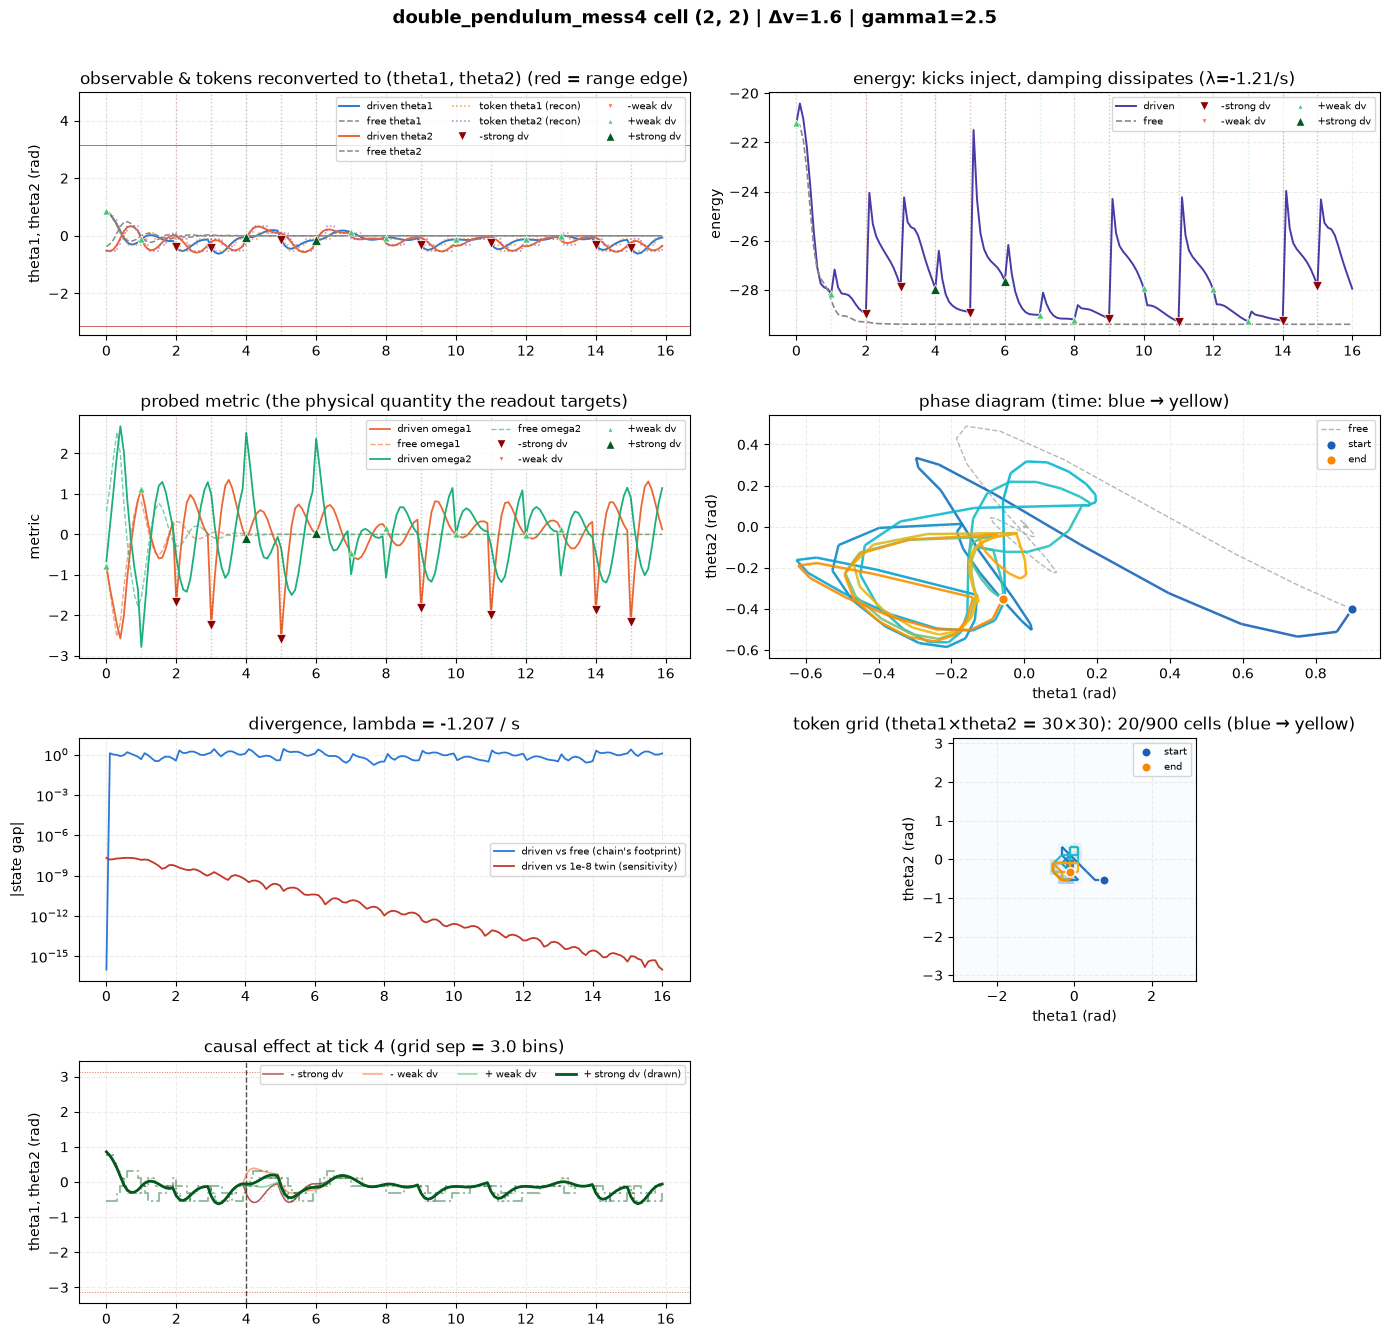


Single-seed (seed=5) trace diagnostics:
  Stability:     STABLE (GO)
  Lyapunov:      -1.207/s
  Clipped:       0.0%
  Used bins:     20/900
  Bayes gap:     0.281 nats
  Sync length:   7 letters


In [14]:
# Researcher inspection coordinates (index into the system's grid):
INSPECT_SYSTEM = "double_pendulum_mess4"
INSPECT_DV = 2  # Δv index in GRIDS[INSPECT_SYSTEM]["delta_v_values"]
INSPECT_DAMPING = 2  # damping index in GRIDS[INSPECT_SYSTEM]["damping_values"]
INSPECT_SEED = 5
INSPECT_N = 10

grid_spec = GRIDS[INSPECT_SYSTEM]
dv_vals = grid_spec["delta_v_values"]
damp_vals = grid_spec["damping_values"]

dv_val = dv_vals[INSPECT_DV] if isinstance(INSPECT_DV, int) else float(INSPECT_DV)
damp_val = damp_vals[INSPECT_DAMPING] if isinstance(INSPECT_DAMPING, int) else float(INSPECT_DAMPING)

damping_field = grid_results[INSPECT_SYSTEM]["damping_field"]
dt = grid_results[INSPECT_SYSTEM]["dt"]

# Look up screening summary for this cell
cell_stats = next(
    (c for c in grid_results[INSPECT_SYSTEM]["grid"]
     if np.isclose(c["delta_v"], dv_val) and np.isclose(c["damping_value"], damp_val)),
    None
)

print(f"Inspecting gridcell ({INSPECT_DV}, {INSPECT_DAMPING}):")
print(f"  System:        {INSPECT_SYSTEM}")
print(f"  Δv:            {dv_val} (index {INSPECT_DV} of {dv_vals})")
print(f"  {damping_field:14s} {damp_val} (index {INSPECT_DAMPING} of {damp_vals})")
print(f"  dt:            {dt:.4f}")
if cell_stats:
    print(f"  Grid verdict:  {cell_stats['verdict']} (pass_rate: {cell_stats['pass_rate']:.0%}, bayes_gap: {cell_stats['bayes_gap_mean']:.3f} nats, lyapunov: {cell_stats['lyapunov_mean']:+.2f})")

sys_kw = {damping_field: damp_val}
if damping_field == "gamma1":
    sys_kw["gamma2"] = damp_val

proc = make_process(
    INSPECT_SYSTEM,
    system=sys_kw,
    delta_v=dv_val,
    dt=dt,
    m=16,
    n_steps=INSPECT_N
)
tr = V.trace(proc, seed=INSPECT_SEED)
fig = V.plot(
    tr,
    panels=("observable", "energy", "metric", "phase", "divergence", "tokens","causal_effect",),
    title=f"{INSPECT_SYSTEM} cell ({INSPECT_DV}, {INSPECT_DAMPING}) | Δv={dv_val} | {damping_field}={damp_val}",
)
plt.show()

rep = V.stability(tr)
print(f"\nSingle-seed (seed={INSPECT_SEED}) trace diagnostics:")
print(f"  Stability:     {'STABLE (GO)' if rep['stable'] else 'UNSTABLE (NO-GO)'}")
print(f"  Lyapunov:      {rep['lyapunov']:+.3f}/s")
print(f"  Clipped:       {rep['clipped']:.1%}")
print(f"  Used bins:     {rep['used_bins']}/{rep['n_obs']}")
print(f"  Bayes gap:     {rep['bayes_gap']:.3f} nats")
print(f"  Sync length:   {rep['sync_length']} letters")
if rep["reasons"]:
    print("  Reasons:      ", rep["reasons"])


## 10. n recalibration

For surviving (Δv, damping) configs, test n_steps ∈ {5, 10, 15, 20}.
n_steps controls the physical integration steps between consecutive kicks.
More steps = more physical evolution per tick, but lower kick density.

In [15]:
from physics.controls import n_recalibrate

# Top candidates per system from grid screening (up to 4 per system):
SURVIVORS = {}
for sys_name, res in grid_results.items():
    # Sort by pass_rate desc, then bayes_gap desc
    sorted_pass = sorted(res["passing"], key=lambda c: (c["pass_rate"], c["bayes_gap_mean"]), reverse=True)
    if not sorted_pass:
        sorted_pass = sorted(res["grid"], key=lambda c: (c["pass_rate"], c["bayes_gap_mean"]), reverse=True)
    SURVIVORS[sys_name] = [
        {"delta_v": c["delta_v"], "damping": c["damping_value"]}
        for c in sorted_pass[:4]
    ]

print("Selected candidates for n-recalibration:")
for sys_name, cfgs in SURVIVORS.items():
    print(f"  {sys_name}: {len(cfgs)} candidates")

Selected candidates for n-recalibration:
  double_pendulum_mess4: 4 candidates


In [16]:
import pandas as pd

n_results = {}
recal_rows = []

for system_name, configs in SURVIVORS.items():
    dt = grid_results[system_name]["dt"]
    damping_field = grid_results[system_name]["damping_field"]
    for config in configs:
        dv = config["delta_v"]
        damp = config["damping"]
        key = f"{system_name}|dv={dv}|{damping_field}={damp}"
        recal = n_recalibrate(
            system_name,
            delta_v=dv,
            damping_value=damp,
            damping_field=damping_field,
            dt=dt,
            n_values=[5, 10, 15, 20],
            n_seeds=10,
        )
        n_results[key] = recal
        for r in recal:
            recal_rows.append(r)

df_recal = pd.DataFrame(recal_rows)
display(df_recal[["delta_v", "damping_field", "damping_value", "n_steps", "dt", "pass_rate", "lyapunov_mean", "bayes_gap_mean", "verdict"]])

,delta_v,damping_field,damping_value,n_steps,dt,pass_rate,lyapunov_mean,bayes_gap_mean,verdict
0,2.0,gamma1,1.5,5,0.1,1.0,-0.473975,1.009226,GO
1,2.0,gamma1,1.5,10,0.1,1.0,-0.644451,0.342145,GO
2,2.0,gamma1,1.5,15,0.1,1.0,-7.133431,0.179640,GO
3,2.0,gamma1,1.5,20,0.1,1.0,-12.108024,0.103243,NO-GO
4,2.0,gamma1,2.0,5,0.1,1.0,-0.831249,0.766373,GO
5,2.0,gamma1,2.0,10,0.1,1.0,-8.826513,0.276743,GO
6,2.0,gamma1,2.0,15,0.1,1.0,-25.463141,0.150472,GO
7,2.0,gamma1,2.0,20,0.1,1.0,-18.720457,0.089291,NO-GO
8,1.6,gamma1,1.5,5,0.1,1.0,-0.657349,0.721841,GO
9,1.6,gamma1,1.5,10,0.1,1.0,-0.695391,0.274911,GO


## 11. Final configuration summary

The (n, Δv, damping, dt) tuples that passed all checks.
These validated parameter sets are ready to be locked into the training pipeline.

In [17]:
final_rows = []
for system_name, configs in SURVIVORS.items():
    dt = grid_results[system_name]["dt"]
    damping_field = grid_results[system_name]["damping_field"]
    for config in configs:
        key = f"{system_name}|dv={config['delta_v']}|{damping_field}={config['damping']}"
        for nr in n_results.get(key, []):
            if nr["verdict"] == "GO":
                final_rows.append({
                    "system": system_name,
                    "delta_v": config["delta_v"],
                    "damping_field": damping_field,
                    "damping_value": config["damping"],
                    "dt": dt,
                    "n_steps": nr["n_steps"],
                    "pass_rate": nr["pass_rate"],
                    "mean_lyapunov": nr["lyapunov_mean"],
                    "mean_bayes_gap": nr["bayes_gap_mean"],
                })

summary_df = pd.DataFrame(final_rows)
print(f"\n{len(summary_df)} configurations passed all checks across {summary_df['system'].nunique() if len(summary_df) else 0} systems.\n")
if not summary_df.empty:
    display(summary_df.style.format({
        "pass_rate": "{:.0%}",
        "mean_lyapunov": "{:+.3f}",
        "mean_bayes_gap": "{:.3f}",
        "dt": "{:.4f}",
        "delta_v": "{:.4f}",
        "damping_value": "{:.4f}",
    }))
else:
    print("No configurations met strict GO criteria. Check individual grid cell diagnostics above.")

# Save locked optimal physics configuration for downstream pipeline
import json
from pathlib import Path
if not summary_df.empty:
    best_config = summary_df.sort_values(by=["pass_rate", "mean_bayes_gap"], ascending=[False, False]).iloc[0].to_dict()
    out_dir = Path("../experiments/outputs-three-phase")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "winning_physics_config.json"
    out_path.write_text(json.dumps(best_config, indent=2))
    print(f"Locked optimal physics config saved to -> {out_path.name}")
    print(f"Optimal config: system={best_config['system']}, dv={best_config['delta_v']}, damping={best_config['damping_value']}, dt={best_config['dt']}, n={best_config['n_steps']}")



11 configurations passed all checks across 1 systems.



,system,delta_v,damping_field,damping_value,dt,n_steps,pass_rate,mean_lyapunov,mean_bayes_gap
0,double_pendulum_mess4,2.0000,gamma1,1.5000,0.1000,5,100%,-0.474,1.009
1,double_pendulum_mess4,2.0000,gamma1,1.5000,0.1000,10,100%,-0.644,0.342
2,double_pendulum_mess4,2.0000,gamma1,1.5000,0.1000,15,100%,-7.133,0.180
3,double_pendulum_mess4,2.0000,gamma1,2.0000,0.1000,5,100%,-0.831,0.766
4,double_pendulum_mess4,2.0000,gamma1,2.0000,0.1000,10,100%,-8.827,0.277
5,double_pendulum_mess4,2.0000,gamma1,2.0000,0.1000,15,100%,-25.463,0.150
6,double_pendulum_mess4,1.6000,gamma1,1.5000,0.1000,5,100%,-0.657,0.722
7,double_pendulum_mess4,1.6000,gamma1,1.5000,0.1000,10,100%,-0.695,0.275
8,double_pendulum_mess4,1.6000,gamma1,1.5000,0.1000,15,100%,-6.565,0.158
9,double_pendulum_mess4,1.6000,gamma1,2.0000,0.1000,5,100%,-0.896,0.592


Locked optimal physics config saved to -> winning_physics_config.json
Optimal config: system=double_pendulum_mess4, dv=2.0, damping=1.5, dt=0.1, n=5
